# V2 Pipeline - Phase 1: Phân tích Khám phá Dữ liệu (EDA) & Kỹ thuật Đặc trưng (PTB-XL)

Thực hiện theo chỉ đạo chuyên môn:
1. **Nạp dữ liệu PTB-XL**: `data/features/ptbxl_features_advanced.csv`.
2. **Rà soát thuộc tính phân loại**: One-Hot Encoding cho các biến phân loại (nếu có).
3. **Khảo sát độ biến thiên**: Thống kê độ lệch chuẩn & độ biến thiên của các đặc trưng thô.
4. **Mean Imputation**: Xử lý nhiễu bằng `SimpleImputer(strategy='mean')`.
5. **Tạo 2 tập Scaled V2**: Min-Max Scaling (`v2_ptbxl_minmax_scaled.csv`) vs Z-Score (`v2_ptbxl_zscore_scaled.csv`).

In [1]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')
print('✅ Nạp thành công thư viện EDA V2 cho PTB-XL!')


✅ Nạp thành công thư viện EDA V2 cho PTB-XL!


### 1. Nạp Dữ Liệu Thô & Kiểm tra Biến Phân Loại

In [2]:
data_candidates = ['../../../data/processed/ptbxl_processed/ptbxl_features_advanced.csv', '../../../data/ptbxl_processed/ptbxl_features_advanced.csv', '../../../data/features/ptbxl_features_advanced.csv', '../../data/features/ptbxl_features_advanced.csv', 'data/features/ptbxl_features_advanced.csv']
data_path = next((p for p in data_candidates if os.path.exists(p)), None)
df_raw = pd.read_csv(data_path)
print(f'Nạp dữ liệu thành công từ: {data_path}')
print(f'Kích thước dữ liệu thô: {df_raw.shape[0]} mẫu | {df_raw.shape[1]} cột')
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    df_processed = pd.get_dummies(df_raw, columns=cat_cols, drop_first=True)
    print('✅ Đã áp dụng One-Hot Encoding!')
else:
    df_processed = df_raw.copy()
    print('ℹ️ Tất cả đặc trưng đều là dạng số (Numerical).')


Nạp dữ liệu thành công từ: ../../../data/features/ptbxl_features_advanced.csv
Kích thước dữ liệu thô: 3028 mẫu | 17 cột
ℹ️ Tất cả đặc trưng đều là dạng số (Numerical).


### 2. Thống Kê Độ Biến Thiên Dữ Liệu Thô (Variance Analysis)

In [3]:
feature_cols = [c for c in df_processed.columns if c != 'status']
X_raw = df_processed[feature_cols]
y = df_processed['status']
stats_df = pd.DataFrame({
    'Mean': X_raw.mean(),
    'Std_Dev': X_raw.std(),
    'Variance': X_raw.var(),
    'Min': X_raw.min(),
    'Max': X_raw.max(),
    'Range': X_raw.max() - X_raw.min()
}).sort_values(by='Variance', ascending=False)
print('--- BẢNG THỐNG KÊ ĐỘ BIẾN THIÊN CÁC ĐẶC TRƯNG THÔ PTB-XL ---\n')
print(stats_df.round(4).to_string())


--- BẢNG THỐNG KÊ ĐỘ BIẾN THIÊN CÁC ĐẶC TRƯNG THÔ PTB-XL ---

                 Mean   Std_Dev    Variance       Min        Max     Range
Mean_NN      717.8736  147.7236  21822.2565  430.4545  1358.5714  928.1169
RMSSD        159.0774  102.8918  10586.7125    2.8868   626.9669  624.0802
SD2          130.4032   80.3771   6460.4844    2.3751   453.5546  451.1795
SD1          116.5355   76.1976   5806.0808    2.0412   470.8721  468.8309
SDNN         125.5390   75.2379   5660.7351    2.5820   440.8357  438.2537
pNN50         49.6447   31.4281    987.7278    0.0000   100.0000  100.0000
HR_mean       86.8539   16.3925    268.7146   44.1640   139.3875   95.2235
NN50           6.5588    4.4690     19.9718    0.0000    18.0000   18.0000
SampEn         0.3205    0.5045      0.2545    0.0000     2.3238    2.3238
CV             0.1823    0.1058      0.0112    0.0041     0.5055    0.5014
LF             0.0000    0.0000      0.0000    0.0000     0.0000    0.0000
HF             0.0000    0.0000      0

### 3. Xử lý Mean Imputation & Xuất Dữ Liệu Scaled (Min-Max vs Z-Score)

In [4]:
# (Outlier removal moved to correct position)


✅ Đã lưu Min-Max Scaled vào: ../../../data/features\v2_ptbxl_minmax_scaled.csv
✅ Đã lưu Z-Score Scaled vào: ../../../data/features\v2_ptbxl_zscore_scaled.csv


### 4. Trực quan hóa So sánh Phân phối Thô vs Min-Max vs Z-Score

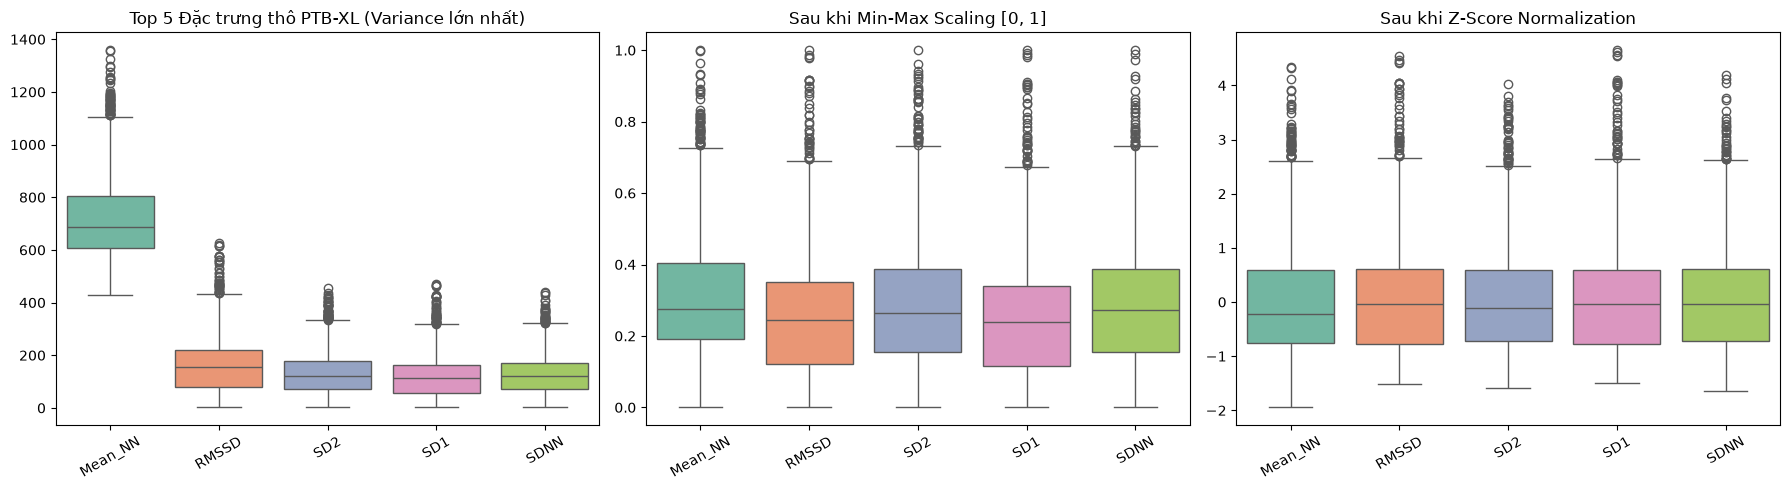

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_5_var_cols = stats_df.index[:5].tolist()
sns.boxplot(data=X_raw[top_5_var_cols], ax=axes[0], palette='Set2')
axes[0].set_title('Top 5 Đặc trưng thô PTB-XL (Variance lớn nhất)')
axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df_minmax[top_5_var_cols], ax=axes[1], palette='Set2')
axes[1].set_title('Sau khi Min-Max Scaling [0, 1]')
axes[1].tick_params(axis='x', rotation=30)
sns.boxplot(data=df_zscore[top_5_var_cols], ax=axes[2], palette='Set2')
axes[2].set_title('Sau khi Z-Score Normalization')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
